# Example-10: Closed orbit

In [1]:
# Import

import numpy
import pandas
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

False


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Corrector errors can be added to each sector between locations
# Thin corrector kicks are applied at the entrance of each sector

# Closed orbit is computed by make_trasport using analytical expression for closed orbit
# If exact falg is true, orbit is computed by minimize with initial guess from the analytical expression
# For linear system, the analytical expression gives exact result, no need to use minimize

# Transport matrices are computed around closed orbit
# But for linear system, thin correctors do not change transport matrices

In [4]:
# Generate test trajectories for uncoupled model

# Set uncoupled model

model = Model(path='../config_uncoupled.yaml', model='uncoupled', dtype=dtype, device=device)

# Set errors

model.make_error(1.0E-3, 1.0E-3, length=0.01, angle_x=1.0E-3, angle_y=1.0E-3)

# Compute transport

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

# Set initial condition

state = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**10

# Generate trajectories

trajectory =  model.make_trajectory(state, length, error=True, transport=False)
print(trajectory.shape)

True
torch.Size([59, 1024, 4])


In [5]:
# make_transport sets orbit attribute (closed orbit for each location)

print(model.orbit.shape)

# Test closed orbit

orbit, *_ = model.orbit
print(orbit)
print(model.map_transport(orbit, 0, model.size))
print(torch.allclose(orbit, model.map_transport(orbit, 0, model.size)))
print(torch.allclose(model.orbit, model.make_trajectory(orbit, 1).squeeze(1)))

torch.Size([59, 4])
tensor([-1.690905297286e-02, -1.507932566224e-03,  4.625458566256e-02,
        -5.166653687858e-03], dtype=torch.float64)
tensor([-1.690905297286e-02, -1.507932566224e-03,  4.625458566256e-02,
        -5.166653687858e-03], dtype=torch.float64)
True
True


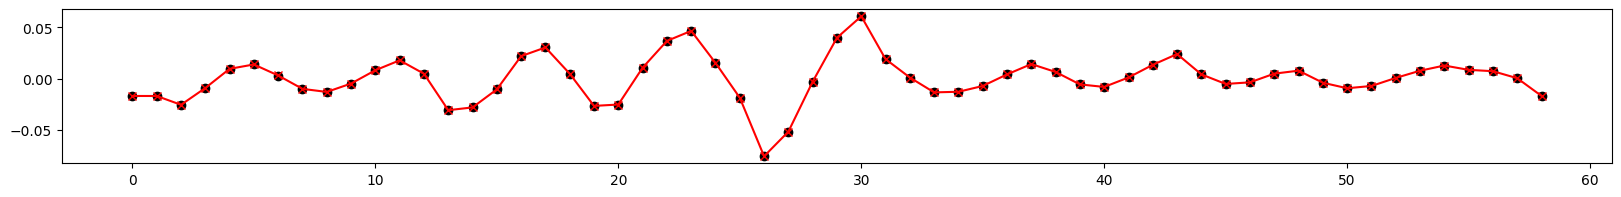

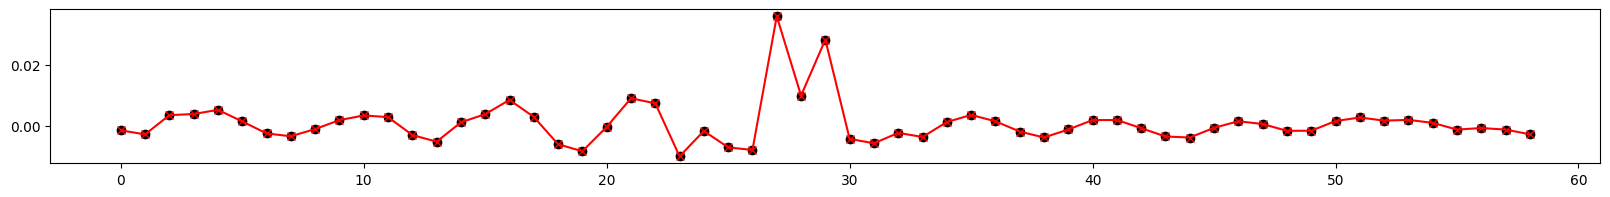

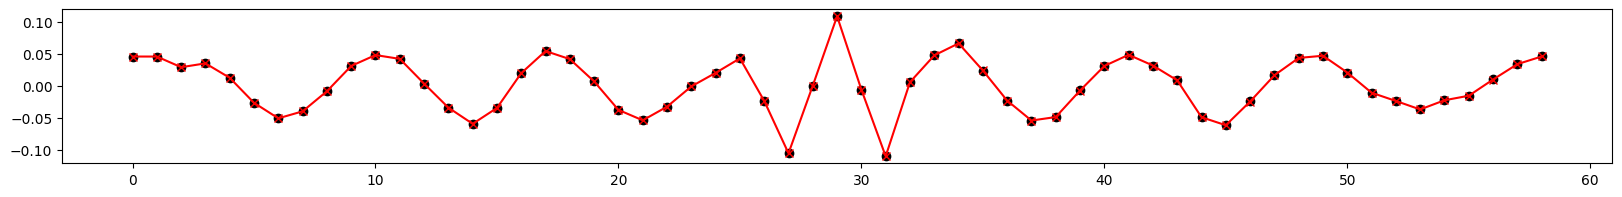

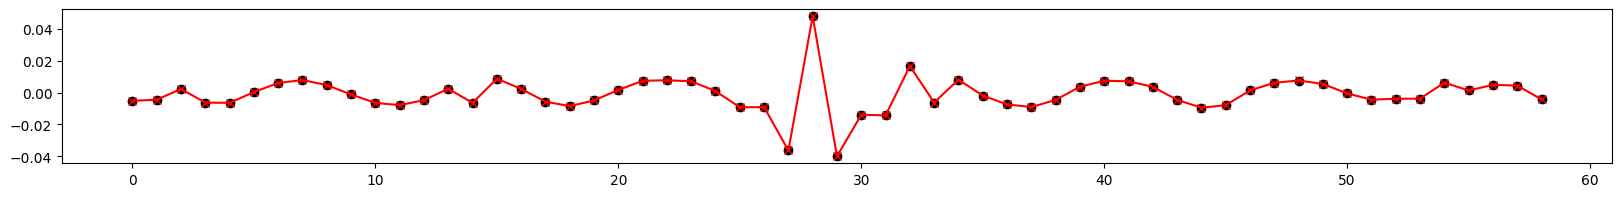

In [6]:
# Compare closed orbits

for plane in range(len(state)):
    plt.figure(figsize=(20, 2))
    plt.plot(range(model.size), model.orbit[:, plane], color='red', marker='x')
    plt.scatter(range(model.size), trajectory[..., plane].mean(1), color='black', marker='o')
    plt.show()